In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [ ]:
X_test = pd.read_csv("X_test.csv", index_col=0)
X_train = pd.read_csv("X_train.csv", index_col=0)
y_test = pd.read_csv("Y_test.csv", index_col=0).squeeze()
y_train = pd.read_csv("Y_train.csv", index_col=0).squeeze()
#shape df correctly for sklearn


BASELINE LOGISTIC REGRESSION

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print(classification_report(y_test, baseline_pred))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.67      0.77      0.71        13
        LumA       0.88      0.90      0.89        87
        LumB       0.78      0.76      0.77        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.86       190
   macro avg       0.85      0.85      0.85       190
weighted avg       0.87      0.86      0.86       190



Explanation:
Overall accuracy: 86% of patients are classified correctly
Macro avg.: 85% -> All the subtypes are contributing equally

FEATURE SELECTION

In [6]:
#from sklearn.feature_selection import SelectKBest, f_classif

#selector = SelectKBest(score_func=f_classif, k=500)

#X_train_selected = selector.fit_transform(X_train, y_train)
#X_test_selected = selector.transform(X_test) #avoid leakage

Some Features have become constant in the dataset: [  814  1240  2646  4851  9848 10556 12074 13252]


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipe_anova_logreg = Pipeline([
    ("variance", VarianceThreshold()),          #removes train-constant genes
    ("select", SelectKBest(score_func=f_classif, k=500)),  #selects top 500 genes
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

pipe_anova_logreg.fit(X_train, y_train)

pred_anova_logreg = pipe_anova_logreg.predict(X_test)

print(classification_report(y_test, pred_anova_logreg))

              precision    recall  f1-score   support

       Basal       0.96      0.93      0.95        28
        Her2       0.85      0.85      0.85        13
        LumA       0.92      0.91      0.91        87
        LumB       0.83      0.89      0.86        38
      Normal       0.91      0.88      0.89        24

    accuracy                           0.90       190
   macro avg       0.89      0.89      0.89       190
weighted avg       0.90      0.90      0.90       190



compared to baseline imporvements can be ssen in:
 -overall accuracy 
 -macro avg.
 -Her2


CONFUSION MATRIX

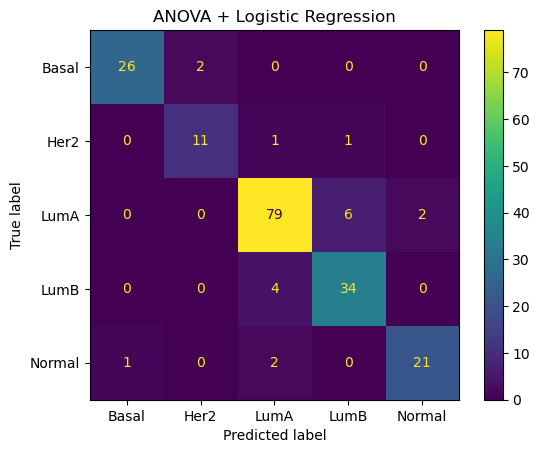

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, pred_anova_logreg)
plt.title("ANOVA + Logistic Regression")
plt.show()

High confusion between LumA and LumB 
Almost no confusion in Basal

SELECTED GENES

In [10]:
# get mask of selected features
selected_mask = pipe_anova_logreg.named_steps["select"].get_support()

# apply mask to original column names
selected_genes = X_train.columns[
    pipe_anova_logreg.named_steps["variance"].get_support()
][selected_mask]

selected_genes

Index(['HIF3A', 'LRRTM2', 'CAMKV', 'GTSE1', 'THSD4', 'CHST3', 'CHST2', 'GPSM2',
       'ZNF703', 'CKS1B',
       ...
       'KIAA1370', 'MMRN2', 'WDR67', 'CX3CL1', 'KCNK15', 'OVCH2', 'NCAPD2',
       'SLC6A14', 'FXYD1', 'KDM4B'],
      dtype='str', length=500)

COMPARISON TABLE

In [14]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")
baseline_her2_recall = recall_score(
    y_test,
    baseline_pred,
    labels=["Her2"],
    average=None
)[0]

print(baseline_accuracy)
print(baseline_macro_f1)
print(baseline_her2_recall)

0.8631578947368421
0.8461125336444486
0.7692307692307693


In [15]:
anova_accuracy = accuracy_score(y_test, pred_anova_logreg)
anova_macro_f1 = f1_score(y_test, pred_anova_logreg, average="macro")
anova_her2_recall = recall_score(
    y_test,
    pred_anova_logreg,
    labels=["Her2"],
    average=None
)[0]

print(anova_accuracy)
print(anova_macro_f1)
print(anova_her2_recall)

0.9
0.891855940848747
0.8461538461538461


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Logistic Regression",
        "ANOVA + Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        anova_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        anova_macro_f1
    ],
    "Her2 Recall": [
        baseline_her2_recall,
        anova_her2_recall
    ],
    "Number of Features": [
        X_train.shape[1],
        500
    ]
})

comparison

,Model,Accuracy,Macro F1,Her2 Recall,Number of Features
0,Baseline Logistic Regression,0.863158,0.846113,0.769231,16162
1,ANOVA + Logistic Regression,0.900000,0.891856,0.846154,500


In [17]:
comparison_rounded = comparison.copy()

comparison_rounded["Accuracy"] = comparison_rounded["Accuracy"].round(3)
comparison_rounded["Macro F1"] = comparison_rounded["Macro F1"].round(3)
comparison_rounded["Her2 Recall"] = comparison_rounded["Her2 Recall"].round(3)

comparison_rounded

,Model,Accuracy,Macro F1,Her2 Recall,Number of Features
0,Baseline Logistic Regression,0.863,0.846,0.769,16162
1,ANOVA + Logistic Regression,0.900,0.892,0.846,500


HYPERTUNING k

In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "select__k": [50, 100, 200, 500, 1000, 2000],
    "model__C": [0.01, 0.1, 1, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best k:", grid.best_params_["select__k"])
print("Best C:", grid.best_params_["model__C"])
print("Best CV score:", grid.best_score_)

Best k: 500
Best C: 0.1
Best CV score: 0.9131416606750831


CHECKING BEST MODEL

In [19]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Basal       1.00      0.93      0.96        28
        Her2       0.85      0.85      0.85        13
        LumA       0.93      0.92      0.92        87
        LumB       0.83      0.89      0.86        38
      Normal       0.92      0.92      0.92        24

    accuracy                           0.91       190
   macro avg       0.90      0.90      0.90       190
weighted avg       0.91      0.91      0.91       190

[[26  2  0  0  0]
 [ 0 11  0  2  0]
 [ 0  0 80  5  2]
 [ 0  0  4 34  0]
 [ 0  0  2  0 22]]
